
## Introduction

Goal: Predict if a song is poplar or not popular using Spotify features.

Focus: Reasoning and evaluation, not perfect accuracy.


## 1. Import Libreryes

We begin by importing all the necessary libraries for data handling, visualization, and machine learning.
	•	pandas, numpy → for working with data.

	•	matplotlib → for creating graphs and charts.

	•	scikit-learn (train_test_split, LogisticRegression, metrics) → for splitting data, building models, and      evaluating performance.

	•	imblearn (RandomOverSampler) → for balancing the dataset when one class is much larger than the other.


In [44]:
# Core
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ML
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, f1_score, ConfusionMatrixDisplay
)

# Imbalance handling
from imblearn.over_sampling import RandomOverSampler

RANDOM_STATE = 42
pd.set_option("display.max_columns", None)

Explanation:

	•pandas and numpy → to process and transform the dataset.
	•matplotlib → to visualize distributions and results.
	•train_test_split → divides the dataset into training (to build the model)
	and test (to evaluate it).
	•LogisticRegression → a simple baseline classification model.
	•accuracy_score, classification_report, f1_score, ConfusionMatrixDisplay
	→ to measure how well the model works.
	•RandomOverSampler → ensures both classes (popular / not popular)
	have the same size by duplicating minority samples.


## 2. Load the Dataset

We load the CSV file containing Spotify data and check the first rows to ensure everything looks correct.

In [45]:
# Load your local CSV (keep the exact filename you have)
CSV_PATH = "Popular_Spotify_Songs (1).csv"
df = pd.read_csv(CSV_PATH, encoding="latin1")

# Quick sanity check
print(df.shape)
df.head()

(953, 24)


,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,in_apple_charts,in_deezer_playlists,in_deezer_charts,in_shazam_charts,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,263,45,10,826,125,B,Major,80,89,83,31,0,8,4
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,126,58,14,382,92,C#,Major,71,61,74,7,0,10,4
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,207,91,14,949,138,F,Major,51,32,53,17,0,31,6
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,207,125,12,548,170,A,Major,55,58,72,11,0,11,15
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,133,87,15,425,144,A,Minor,65,23,80,14,63,11,6


Explanation:

	•	pd.read_csv(...) → loads the dataset into a DataFrame (df).
	•	encoding='latin1' → avoids issues with special characters (e.g., Swedish or accented letters).
	•	df.head() → prints the first five rows so we can verify the structure of the data.

## 3. Create Target Column (Popularity Label)

Here we classify songs into popular or not popular based on how many playlists they appear in.
We start with the threshold = 5000. Later, we can experiment with 3000 or 7000 as your teacher suggested.

In [46]:
# Define a function to classify songs based on playlist count
def classify_popularity(playlist_count):                    # input = number of playlists
    if playlist_count >= 5000:                              # threshold = 5000 playlists
        return "populär"                                    # considered popular
    else:
        return "inte populär"                               # considered not popular

# Apply the function to create a new column
df["popularity_category"] = df["in_spotify_playlists"].apply(classify_popularity)

# Show counts of each category
print("Counts at threshold=5000:")
print(df["popularity_category"].value_counts())

Counts at threshold=5000:
popularity_category
inte populär    692
populär         261
Name: count, dtype: int64


Explanation:

	•	classify_popularity: function that checks if a song has ≥5000 playlists.
	•	If yes → “populär”, otherwise “inte populär”.
	•	We then create a new column popularity_category in the dataset.
	•	Finally, we print the distribution of the two classes.

## 4. Visualize Class Distribution (Before Balancing)

This step shows how many songs fall into “populär” vs “inte populär” at the chosen threshold (5000).
Your teacher specifically asked for this, since imbalance can affect model performance.

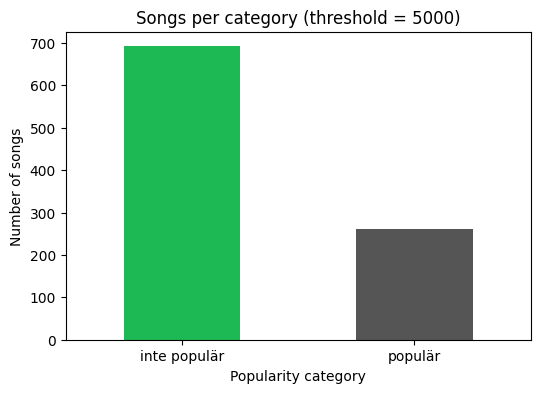


Class distribution (percent):
popularity_category
inte populär    72.612802
populär         27.387198
Name: count, dtype: float64


In [47]:
# Count how many songs are in each category
class_counts = df["popularity_category"].value_counts()

# Plot the distribution
plt.figure(figsize=(6, 4))
class_counts.plot(kind="bar", color=["#1DB954", "#555555"])   # Spotify green & grey
plt.title("Songs per category (threshold = 5000)")
plt.xlabel("Popularity category")
plt.ylabel("Number of songs")
plt.xticks(rotation=0)
plt.show()

# Print percentages for clarity
print("\nClass distribution (percent):")
print(class_counts / len(df) * 100)

Explanation:

	•	value_counts() → counts how many songs are popular vs not popular.
	•	A bar chart makes imbalance visible (e.g., 70% “inte populär”, 30% “populär”).
	•	We also print the percentages, since the examiner asked for this reasoning.

# 5.Encode Categorical Features & Select Final Features

Machine learning models only work with numbers, so we must convert text (categorical variables) like mode and key into numeric values. Then we pick which features we’ll use to train the model.

In [48]:
# Encode 'mode' → Major = 1, Minor = 0
df["mode_encoded"] = df["mode"].map({"Major": 1, "Minor": 0})

# One-hot encode the musical key (creates dummy columns: key_A, key_B, etc.)
df = pd.get_dummies(df, columns=["key"], prefix="key")

# Define candidate feature set
feature_columns = [
    "bpm",
    "danceability_%",
    "valence_%",
    "energy_%",
    "acousticness_%",
    "instrumentalness_%",
    "liveness_%",
    "speechiness_%",
    "released_year",        # added after teacher feedback (strong correlation)
    "mode_encoded"
]

# X = input features, y = target labels
X = df[feature_columns]
y = df["popularity_category"]

print("Selected features:", feature_columns)#

Selected features: ['bpm', 'danceability_%', 'valence_%', 'energy_%', 'acousticness_%', 'instrumentalness_%', 'liveness_%', 'speechiness_%', 'released_year', 'mode_encoded']


Explanation:

	•	mode_encoded: We turn text into numbers (Major = 1, Minor = 0).
	•	key: Converted with one-hot encoding → each key becomes its own
	    column (key_A, key_B, …).
	•	Teacher’s feedback: We now include released_year since it had a relatively high absolute
	    correlation (≈ -0.39). Negative or positive doesn’t matter — strong correlation helps.
	•	X and y:
	•	X = input features (used for training).
	•	y = target label (popular vs not popular).


## 6. Baseline Model (Without Balancing

We first train a simple Logistic Regression on the original (imbalanced) dataset. This gives us a baseline to compare against later.


🔹 Baseline accuracy: 0.8010471204188482

🔹 Classification report (Baseline):

              precision    recall  f1-score   support

inte populär       0.79      0.99      0.88       139
     populär       0.89      0.31      0.46        52

    accuracy                           0.80       191
   macro avg       0.84      0.65      0.67       191
weighted avg       0.82      0.80      0.76       191



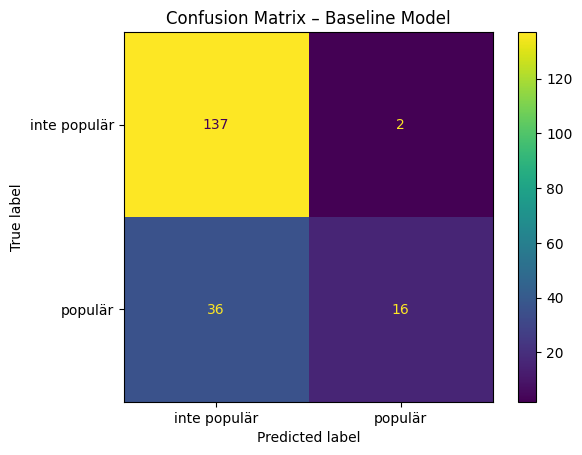

🔹 Baseline Macro-F1: 0.6676739926739926


In [49]:
# Split dataset into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Train baseline Logistic Regression
baseline_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
baseline_model.fit(X_train, y_train)

# Predictions on the test set
y_pred_base = baseline_model.predict(X_test)

# Evaluate baseline model
print("🔹 Baseline accuracy:", accuracy_score(y_test, y_pred_base))
print("\n🔹 Classification report (Baseline):\n")
print(classification_report(y_test, y_pred_base, zero_division=0))

# Confusion Matrix for visual clarity
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_base, labels=["inte populär", "populär"])
plt.title("Confusion Matrix – Baseline Model")
plt.show()

# Extra: Macro-F1 score
print("🔹 Baseline Macro-F1:", f1_score(y_test, y_pred_base, average="macro"))

Explanation:

	•	train_test_split: Splits data into train (80%) and test (20%). We use stratify=y to preserve the same class balance in both sets.
	•	LogisticRegression: A simple linear classifier. max_iter=1000 avoids convergence warnings.
	•	Evaluation:
	•	Accuracy: How many predictions are correct.
	•	Classification Report: Shows precision, recall, and F1-score per class.
	•	Confusion Matrix: Visualizes correct vs incorrect predictions.
	•	Macro-F1: Teacher recommended → averages performance equally across classes.
	•	This is the starting point. Because the dataset is imbalanced, we expect the model to perform better at predicting “inte populär” and worse at “populär”.

## 7. Balance the Dataset (Oversampling)

We saw earlier that the dataset is imbalanced (many more “inte populär” songs than “populär”).
To make the model learn more fairly, we apply oversampling → duplicate minority-class samples until both classes are equal.

🔹 Class counts after balancing:
popularity_category
inte populär    692
populär         692
Name: count, dtype: int64

🔹 Class share after balancing:
popularity_category
inte populär    0.5
populär         0.5
Name: proportion, dtype: float64


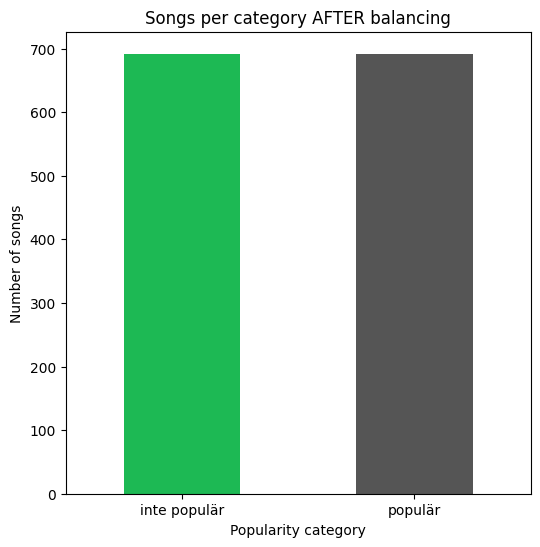

In [50]:
# Initialize oversampler
oversampler = RandomOverSampler(random_state=RANDOM_STATE)

# Apply oversampling to features (X) and labels (y)
X_resampled, y_resampled = oversampler.fit_resample(X, y)

# Check new class distribution
print("🔹 Class counts after balancing:")
print(y_resampled.value_counts())
print("\n🔹 Class share after balancing:")
print(y_resampled.value_counts(normalize=True).round(3))

# Visualize balanced distribution
plt.figure(figsize=(6,6))
y_resampled.value_counts().plot(kind="bar", color=["#1DB954", "#555555"])
plt.title("Songs per category AFTER balancing")
plt.xlabel("Popularity category")
plt.ylabel("Number of songs")
plt.xticks(rotation=0)
plt.show()

Explanation:

	•	RandomOverSampler: Copies rows from the minority class (“populär”)
	     until both classes are equally represented.
	•	fit_resample(X, y): Produces new balanced X_resampled, y_resampled.
	•	Value counts: Now each class should have the same number of samples (≈50/50).
	•	Plot: The bar chart clearly shows the new balanced dataset.

8. Train Model on the Balanced Dataset

We retrain Logistic Regression using the oversampled data and compare to the baseline.




🔹 Oversampled accuracy: 0.7725631768953068

🔹 Classification report (Oversampled):

              precision    recall  f1-score   support

inte populär       0.72      0.88      0.80       139
     populär       0.85      0.66      0.74       138

    accuracy                           0.77       277
   macro avg       0.79      0.77      0.77       277
weighted avg       0.79      0.77      0.77       277



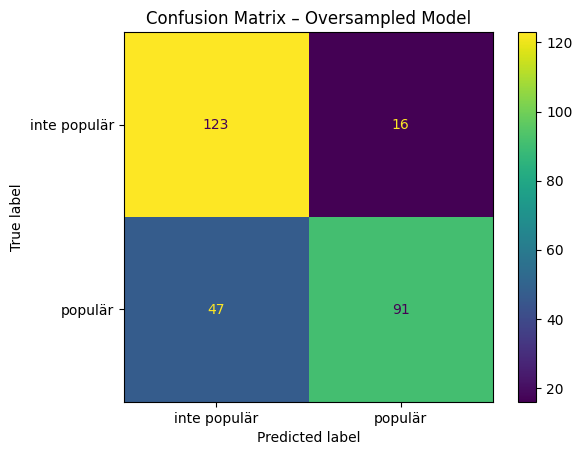

🔹 Oversampled Macro-F1: 0.769486823855756


In [51]:
# Split balanced data into train/test
X_train_os, X_test_os, y_train_os, y_test_os = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=RANDOM_STATE, stratify=y_resampled
)

# Train Logistic Regression on balanced data
model_os = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
model_os.fit(X_train_os, y_train_os)

# Predict on test split
y_pred_os = model_os.predict(X_test_os)

# Evaluate balanced model
print("🔹 Oversampled accuracy:", accuracy_score(y_test_os, y_pred_os))
print("\n🔹 Classification report (Oversampled):\n")
print(classification_report(y_test_os, y_pred_os, zero_division=0))

# Confusion Matrix for oversampled model
ConfusionMatrixDisplay.from_predictions(y_test_os, y_pred_os, labels=["inte populär", "populär"])
plt.title("Confusion Matrix – Oversampled Model")
plt.show()

# Macro-F1 (teacher asked for this)
print("🔹 Oversampled Macro-F1:", f1_score(y_test_os, y_pred_os, average="macro"))

Explanation:

	•	We split the balanced dataset into train/test with stratify to keep 50/50 in both.
	•	We train the same Logistic Regression to make a fair comparison with baseline.
	•	We report accuracy, classification report, confusion matrix, and macro-F1.
	•	Expectation: Macro-F1 and recall for “populär” usually improve after balancing, even if accuracy moves slightly.